# Grievance: Root-Cause Discovery and Resolution Outcome Prediction for Consumer Financial Complaints

## Project Overview

This project focuses on analyzing consumer financial complaints to identify major complaint root causes, resolution outcomes, response patterns, and trends.

### Industry
Consumer Financial Services

### Organization
Consumer Financial Protection Bureau (CFPB)

### Dataset
Consumer Financial Complaints Dataset

### Sprint 1 Objective
- Data Cleaning
- Data Quality Analysis
- Exploratory Data Analysis
- Root-Cause Discovery
- Resolution Outcome Analysis
- Business Insights

### Import Libraries

In [1]:
# -> Import required libraries for EDA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Load Dataset

In [2]:
# -> Load the consumer financial complaints dataset
data=pd.read_csv(r"D:\AI & ML\Consumer_Financial_Complaints\Dataset\Consumer Financial Complaints.csv")

print("Dataset loaded successfully.")
print("Dataset Shape:", data.shape)

Dataset loaded successfully.
Dataset Shape: (47053, 15)


### Create Raw and Clean Dataset

In [3]:
# -> Create raw and clean dataset backups

raw_data = data.copy()
clean_data = data.copy()

print("Raw dataset shape:", raw_data.shape)
print("Clean dataset shape:", clean_data.shape)

Raw dataset shape: (47053, 15)
Clean dataset shape: (47053, 15)


### Display Clean Dataset

In [4]:
# -> Preview the cleaned dataset

print("Display first few rows in Consumer Financial Complaints Clean Dataset")

clean_data.head()

Display first few rows in Consumer Financial Complaints Clean Dataset


,Date received,Product,Sub-product,Issue,Sub-issue,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2026-08-01T00:08:18.000Z,Debt collection,I do not know,Took or threatened to take negative or legal a...,Threatened or suggested your credit would be d...,NaN,CL Holdings LLC,TX,77073,NaN,Web,2026-08-01T00:10:13.000Z,Closed with non-monetary relief,Yes,24837071
1,2026-08-01T00:04:33.000Z,Vehicle loan or lease,Loan,Managing the loan or lease,Problem with additional products or services p...,Company has responded to the consumer and the ...,WELLS FARGO & COMPANY,NH,03077,NaN,Web,2026-08-01T00:30:23.000Z,Closed with explanation,Yes,24837675
2,2026-08-01T00:26:56.000Z,Debt collection,I do not know,Attempts to collect debt not owed,Debt was result of identity theft,NaN,"Portfolio Recovery Associates, LLC",FL,33170,NaN,Web,2026-08-01T00:33:45.000Z,Closed with non-monetary relief,Yes,24837758
3,2026-08-01T00:27:25.000Z,Debt collection,I do not know,Attempts to collect debt not owed,Debt is not yours,Company believes it acted appropriately as aut...,"CCS Financial Services, Inc.",NC,27609,NaN,Web,2026-08-01T01:14:23.000Z,Closed with explanation,Yes,24837863
4,2026-08-01T00:13:31.000Z,Debt collection,Other debt,Attempts to collect debt not owed,Debt was result of identity theft,NaN,CL Holdings LLC,MA,02302,NaN,Web,2026-08-01T00:16:20.000Z,Closed with non-monetary relief,Yes,24837234


### Dataset Information

In [5]:
# ->  Inspect dataset columns and data types
clean_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 47053 entries, 0 to 47052
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   Date received                 47053 non-null  str  
 1   Product                       47053 non-null  str  
 2   Sub-product                   47053 non-null  str  
 3   Issue                         47053 non-null  str  
 4   Sub-issue                     42069 non-null  str  
 5   Company public response       11570 non-null  str  
 6   Company                       47053 non-null  str  
 7   State                         46775 non-null  str  
 8   ZIP code                      46659 non-null  str  
 9   Tags                          5868 non-null   str  
 10  Submitted via                 47053 non-null  str  
 11  Date sent to company          47053 non-null  str  
 12  Company response to consumer  47053 non-null  str  
 13  Timely response?              47053 non-nu

In [6]:
# -> Display dataset dimensions and data types

print("Consumer Financial Complaints Dataset Information")
print("=" * 60)

print("Number of Rows:", clean_data.shape[0])
print("Number of Columns:", clean_data.shape[1])

print("\nData Types:")
print(clean_data.dtypes)

Consumer Financial Complaints Dataset Information
Number of Rows: 47053
Number of Columns: 15

Data Types:
Date received                     str
Product                           str
Sub-product                       str
Issue                             str
Sub-issue                         str
Company public response           str
Company                           str
State                             str
ZIP code                          str
Tags                              str
Submitted via                     str
Date sent to company              str
Company response to consumer      str
Timely response?                  str
Complaint ID                    int64
dtype: object


In [7]:
# ->Count values across all dataset columns
clean_data.isna().sum()

Date received                       0
Product                             0
Sub-product                         0
Issue                               0
Sub-issue                        4984
Company public response         35483
Company                             0
State                             278
ZIP code                          394
Tags                            41185
Submitted via                       0
Date sent to company                0
Company response to consumer        0
Timely response?                    0
Complaint ID                        0
dtype: int64

In [8]:
# ->  Display all dataset column names

print("Columns in the dataset:\n")

for i, column in enumerate(clean_data.columns, start=1):
    print(i, "->", column)

Columns in the dataset:

1 -> Date received
2 -> Product
3 -> Sub-product
4 -> Issue
5 -> Sub-issue
6 -> Company public response
7 -> Company
8 -> State
9 -> ZIP code
10 -> Tags
11 -> Submitted via
12 -> Date sent to company
13 -> Company response to consumer
14 -> Timely response?
15 -> Complaint ID


### Dataset Statistical Summary

In [9]:
# ->  Generate descriptive statistics for the dataset
clean_data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date received,47053,46196,2026-08-11T20:55:31.000Z,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,47053,10,Debt collection,20027,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sub-product,47053,51,I do not know,12373,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Issue,47053,82,Attempts to collect debt not owed,10200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sub-issue,42069,202,Debt is not yours,7596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Company public response,11570,10,Company has responded to the consumer and the ...,9742,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Company,47053,1467,CAPITAL ONE FINANCIAL CORPORATION,2175,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,46775,60,TX,5812,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ZIP code,46659,10841,XXXXX,153,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tags,5868,3,Servicemember,2935,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### DUPLICATE ANALYSIS

In [10]:
# ->Check Duplicate Rows

duplicate_count = clean_data.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [11]:
#  remove duplicates only if they actually exist
if duplicate_count > 0:
    clean_data = clean_data.drop_duplicates()
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found.")

No duplicate rows found.


### Standardize Column Names

In [12]:
clean_data.columns = (
    clean_data.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace("?", "", regex=False)
)

print("Updated Column Names:\n")

for i, column in enumerate(clean_data.columns, start=1):
    print(f"{i} -> {column}")

Updated Column Names:

1 -> date_received
2 -> product
3 -> sub_product
4 -> issue
5 -> sub_issue
6 -> company_public_response
7 -> company
8 -> state
9 -> zip_code
10 -> tags
11 -> submitted_via
12 -> date_sent_to_company
13 -> company_response_to_consumer
14 -> timely_response
15 -> complaint_id


### DATA TYPE CONVERSION

In [13]:
clean_data["date_received"] = pd.to_datetime(
    clean_data["date_received"],
    errors="coerce"
)

clean_data["date_sent_to_company"] = pd.to_datetime(
    clean_data["date_sent_to_company"],
    errors="coerce"
)

clean_data["zip_code"] = (
    pd.to_numeric(
        clean_data["zip_code"],
        errors="coerce"
    )
    .fillna(0)
    .astype(int)
)

print(clean_data[
    ["date_received", "date_sent_to_company","zip_code"]
].dtypes)

date_received           datetime64[us, UTC]
date_sent_to_company    datetime64[us, UTC]
zip_code                              int64
dtype: object


In [14]:
print(clean_data.dtypes)

date_received                   datetime64[us, UTC]
product                                         str
sub_product                                     str
issue                                           str
sub_issue                                       str
company_public_response                         str
company                                         str
state                                           str
zip_code                                      int64
tags                                            str
submitted_via                                   str
date_sent_to_company            datetime64[us, UTC]
company_response_to_consumer                    str
timely_response                                 str
complaint_id                                  int64
dtype: object


### TEXT CLEANING

In [15]:
text_columns = [
    "product",
    "sub_product",
    "issue",
    "sub_issue",
    "company_public_response",
    "company",
    "state",
    "tags",
    "submitted_via",
    "company_response_to_consumer",
    "timely_response"
]

for column in text_columns:
    clean_data[column] = (
        clean_data[column]
        .astype("string")
        .str.strip()
    )

print("Text columns cleaned successfully.")

Text columns cleaned successfully.


### STATE CLEANING

In [16]:
clean_data["state"] = (
    clean_data["state"]
    .str.upper()
    .str.strip()
)
clean_data["state"].value_counts().head(10)

state
TX    5812
CA    5175
FL    4931
GA    2831
NY    2701
NC    1717
PA    1622
IL    1602
NJ    1461
OH    1371
Name: count, dtype: Int64

### COMPLAINT ID VALIDATION

In [17]:
print("Total Complaint Records:", len(clean_data))
print("Unique Complaint IDs:", clean_data["complaint_id"].nunique())
print(
    "Duplicate Complaint IDs:",
    clean_data["complaint_id"].duplicated().sum()
)

Total Complaint Records: 47053
Unique Complaint IDs: 47053
Duplicate Complaint IDs: 0


### Missing Value Analysis

In [18]:
missing_values = clean_data.isnull().sum()

missing_percentage = (
    clean_data.isnull().sum() / len(clean_data) * 100
).round(2)

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})
missing_values

date_received                       0
product                             0
sub_product                         0
issue                               0
sub_issue                        4984
company_public_response         35483
company                             0
state                             278
zip_code                            0
tags                            41185
submitted_via                       0
date_sent_to_company                0
company_response_to_consumer        0
timely_response                     0
complaint_id                        0
dtype: int64

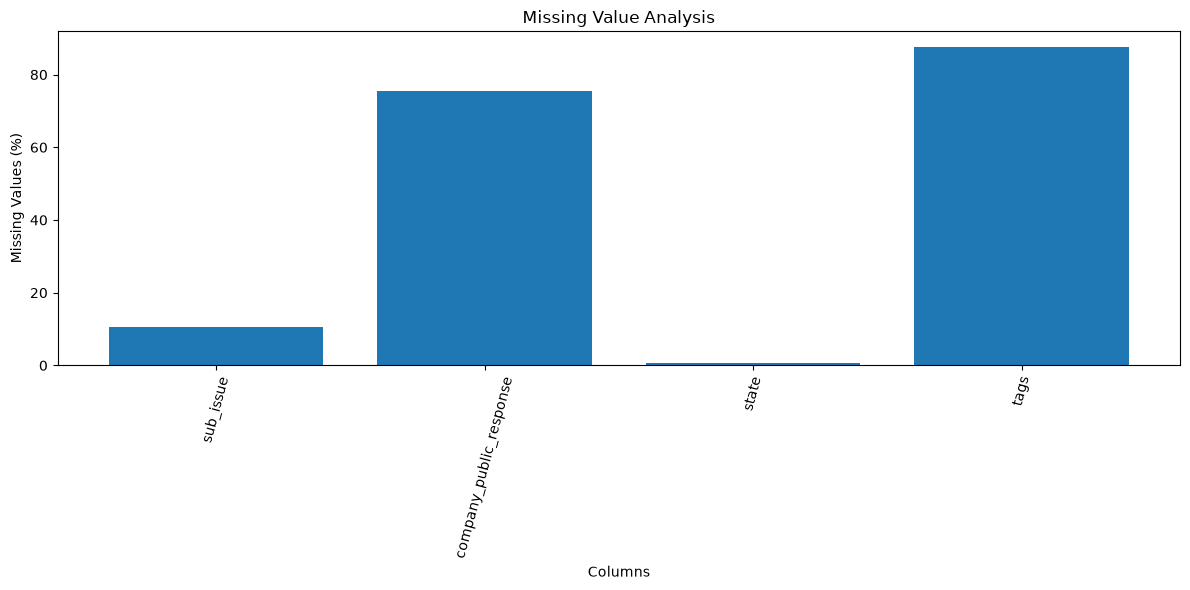

In [19]:
#  Visualize Missing Values
missing_plot = missing_summary[
    missing_summary["Missing Values"] > 0
]

plt.figure(figsize=(12, 6))

plt.bar(
    missing_plot.index,
    missing_plot["Missing Percentage"]
)

plt.xlabel("Columns")
plt.ylabel("Missing Values (%)")
plt.title("Missing Value Analysis")

plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

### MISSING VALUE TREATMENT

In [20]:
clean_data["company_public_response"] = (
    clean_data["company_public_response"]
    .fillna("Not Provided")
)

clean_data["tags"] = (
    clean_data["tags"]
    .fillna("No Tag")
)

clean_data["state"] = (
    clean_data["state"]
    .fillna("Unknown")
)

clean_data["sub_issue"] = (
    clean_data["sub_issue"]
    .fillna("Not Specified")
)

In [21]:
clean_data.isnull().sum()

date_received                   0
product                         0
sub_product                     0
issue                           0
sub_issue                       0
company_public_response         0
company                         0
state                           0
zip_code                        0
tags                            0
submitted_via                   0
date_sent_to_company            0
company_response_to_consumer    0
timely_response                 0
complaint_id                    0
dtype: int64

### FEATURE ENGINEERING

In [22]:
# Response time
clean_data["response_days"] = (clean_data["date_sent_to_company"]- clean_data["date_received"]).dt.days

clean_data[["date_received","date_sent_to_company","response_days"]].head()

,date_received,date_sent_to_company,response_days
0,2026-08-01 00:08:18+00:00,2026-08-01 00:10:13+00:00,0
1,2026-08-01 00:04:33+00:00,2026-08-01 00:30:23+00:00,0
2,2026-08-01 00:26:56+00:00,2026-08-01 00:33:45+00:00,0
3,2026-08-01 00:27:25+00:00,2026-08-01 01:14:23+00:00,0
4,2026-08-01 00:13:31+00:00,2026-08-01 00:16:20+00:00,0


In [23]:
# Check negative values
negative_response = (
    clean_data["response_days"] < 0
).sum()

print(
    "Negative response-time records:",
    negative_response
)

Negative response-time records: 0


In [24]:
# Year
clean_data["year"] = (
    clean_data["date_received"].dt.year
)


### Final Data Quality Check

In [25]:
print("=" * 70)
print("FINAL DATA QUALITY CHECK")
print("=" * 70)

print("\nRows:", clean_data.shape[0])
print("Columns:", clean_data.shape[1])

print("\nDuplicate Rows:")
print(clean_data.duplicated().sum())

print("\nTotal Missing Values:")
print(clean_data.isnull().sum().sum())

print("\nNegative Response Days:")
print((clean_data["response_days"] < 0).sum())

FINAL DATA QUALITY CHECK

Rows: 47053
Columns: 17

Duplicate Rows:
0

Total Missing Values:
0

Negative Response Days:
0


In [26]:
clean_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 47053 entries, 0 to 47052
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype              
---  ------                        --------------  -----              
 0   date_received                 47053 non-null  datetime64[us, UTC]
 1   product                       47053 non-null  string             
 2   sub_product                   47053 non-null  string             
 3   issue                         47053 non-null  string             
 4   sub_issue                     47053 non-null  string             
 5   company_public_response       47053 non-null  string             
 6   company                       47053 non-null  string             
 7   state                         47053 non-null  string             
 8   zip_code                      47053 non-null  int64              
 9   tags                          47053 non-null  string             
 10  submitted_via                 47053 non-null 

### DESCRIPTIVE STATISTICS

In [27]:
clean_data.describe().T

,count,mean,std,min,25%,50%,75%,max
zip_code,47053.0,4.707069e+04,30842.781752,0.0,23225.0,37664.0,77073.0,99901.0
complaint_id,47053.0,2.542512e+07,348783.933472,24837071.0,25125790.0,25420812.0,25720023.0,26778069.0
response_days,47053.0,7.395915e-01,4.659525,0.0,0.0,0.0,0.0,55.0
year,47053.0,2.026000e+03,0.000000,2026.0,2026.0,2026.0,2026.0,2026.0


In [28]:
clean_data.describe(include="string").T

,count,unique,top,freq
product,47053,10,Debt collection,20027
sub_product,47053,51,I do not know,12373
issue,47053,82,Attempts to collect debt not owed,10200
sub_issue,47053,203,Debt is not yours,7596
company_public_response,47053,11,Not Provided,35483
company,47053,1467,CAPITAL ONE FINANCIAL CORPORATION,2175
state,47053,61,TX,5812
tags,47053,4,No Tag,41185
submitted_via,47053,4,Web,44767
company_response_to_consumer,47053,5,Closed with explanation,30599


### Product Analysis

In [29]:
product_counts = clean_data["product"].value_counts()

product_counts

product
Debt collection                                            20027
Credit card                                                 7912
Checking or savings account                                 7466
Money transfer, virtual currency, or money service          3082
Mortgage                                                    2702
Vehicle loan or lease                                       1967
Payday loan, title loan, personal loan, or advance loan     1654
Student loan                                                1415
Prepaid card                                                 513
Debt or credit management                                    315
Name: count, dtype: Int64

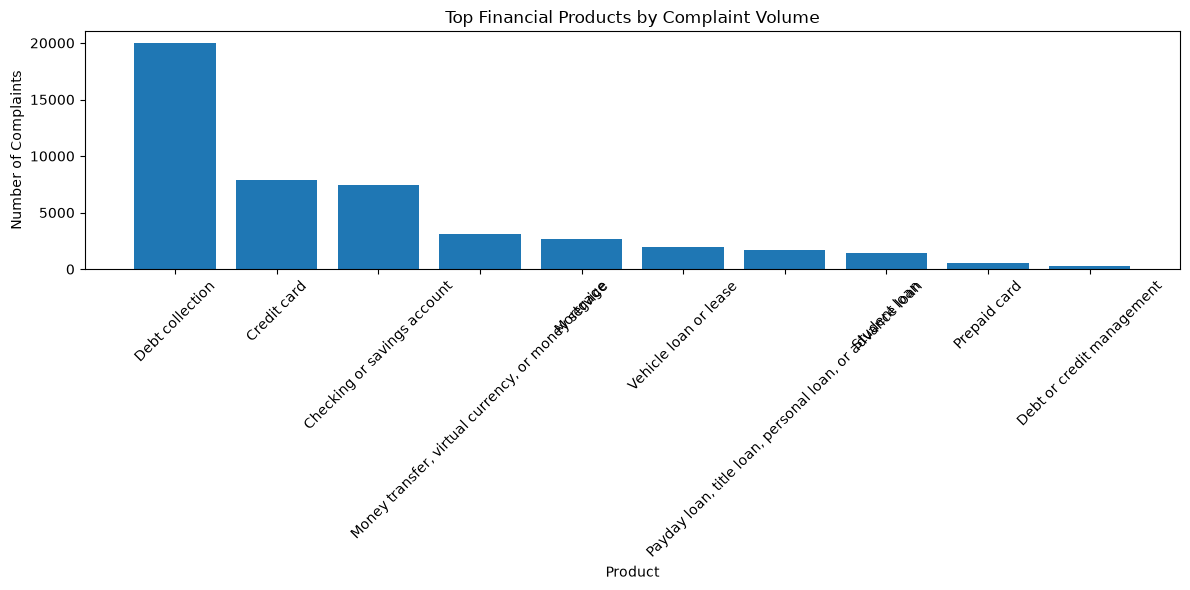

In [30]:
top_products = product_counts.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_products.index,
    top_products.values
)

plt.xlabel("Product")
plt.ylabel("Number of Complaints")
plt.title("Top Financial Products by Complaint Volume")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Issue Analysis

In [31]:
issue_counts = clean_data["issue"].value_counts()

issue_counts.head(15)

issue
Attempts to collect debt not owed                               10200
Managing an account                                              4491
Written notification about debt                                  3551
Took or threatened to take negative or legal action              3079
Problem with a purchase shown on your statement                  2693
False statements or representation                               2027
Trouble during payment process                                   1301
Problem with a lender or other company charging your account     1009
Other features, terms, or problems                                967
Getting a credit card                                             934
Closing an account                                                926
Incorrect information on your report                              906
Dealing with your lender or servicer                              898
Fees or interest                                                  888
Struggling to 

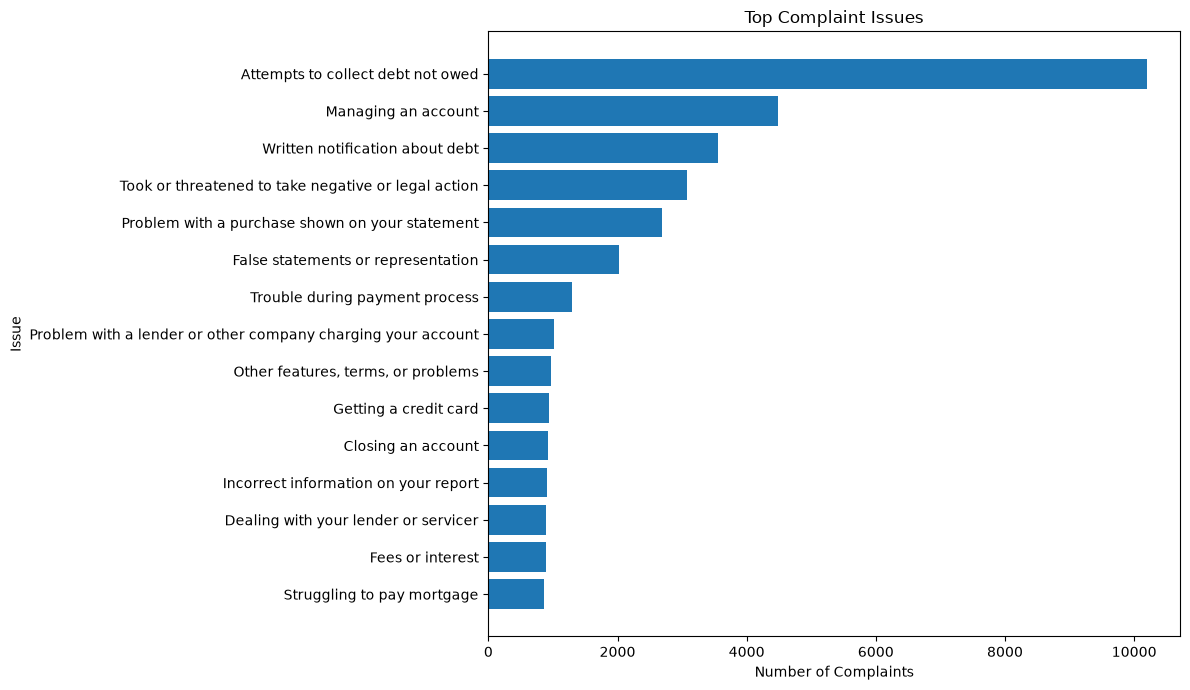

In [32]:
top_issues = issue_counts.head(15)

plt.figure(figsize=(12, 7))

plt.barh(
    top_issues.index[::-1],
    top_issues.values[::-1]
)

plt.xlabel("Number of Complaints")
plt.ylabel("Issue")
plt.title("Top Complaint Issues")

plt.tight_layout()
plt.show()

### Sub-Issue Analysis

In [33]:
sub_issue_counts = (
    clean_data["sub_issue"]
    .value_counts()
)

sub_issue_counts.head(20)

sub_issue
Debt is not yours                                                                   7596
Not Specified                                                                       4984
Threatened or suggested your credit would be damaged                                2742
Didn't receive enough information to verify debt                                    2591
Credit card company isn't resolving a dispute about a purchase on your statement    2091
Attempted to collect wrong amount                                                   1914
Debt was result of identity theft                                                   1856
Deposits and withdrawals                                                            1493
Problem using a debit or ATM card                                                   1249
Company closed your account                                                          854
Transaction was not authorized                                                       817
Card opened

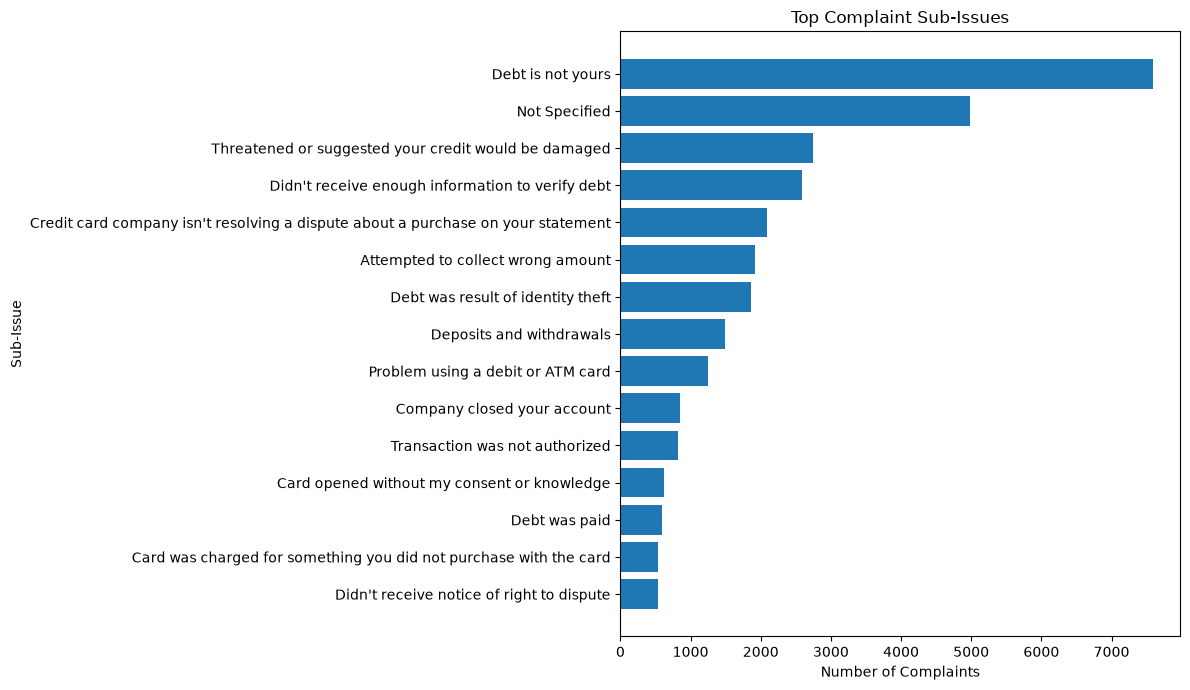

In [34]:
top_sub_issues = sub_issue_counts.head(15)

plt.figure(figsize=(12, 7))

plt.barh(
    top_sub_issues.index[::-1],
    top_sub_issues.values[::-1]
)

plt.xlabel("Number of Complaints")
plt.ylabel("Sub-Issue")
plt.title("Top Complaint Sub-Issues")

plt.tight_layout()
plt.show()

### COMPANY ANALYSIS

In [35]:
company_counts = (
    clean_data["company"]
    .value_counts()
)

company_counts.head(15)

company
CAPITAL ONE FINANCIAL CORPORATION         2175
CL Holdings LLC                           1980
JPMORGAN CHASE & CO.                      1780
BANK OF AMERICA, NATIONAL ASSOCIATION     1616
CITIBANK, N.A.                            1588
WELLS FARGO & COMPANY                     1461
ENCORE CAPITAL GROUP INC.                 1451
Portfolio Recovery Associates, LLC        1400
Resurgent Capital Services L.P.           1251
Block, Inc.                               1231
Paypal Holdings, Inc                      1162
SYNCHRONY FINANCIAL                        999
Chime Financial Inc                        983
Experian Information Solutions Inc.        710
TRANSUNION INTERMEDIATE HOLDINGS, INC.     688
Name: count, dtype: Int64

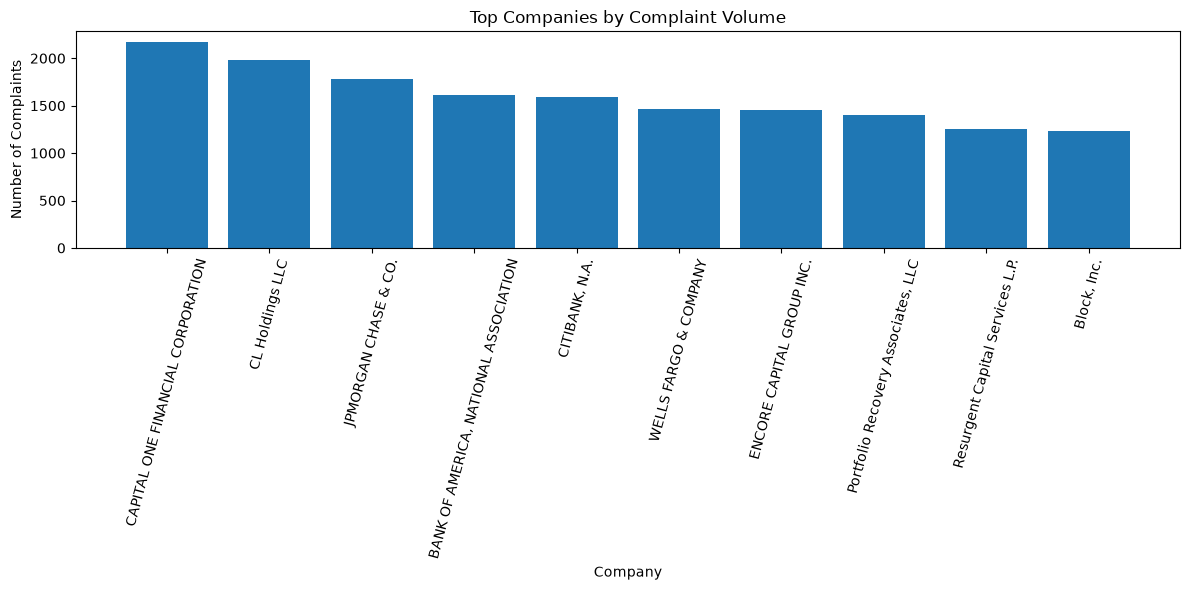

In [36]:
top_companies = company_counts.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_companies.index,
    top_companies.values
)

plt.xlabel("Company")
plt.ylabel("Number of Complaints")
plt.title("Top Companies by Complaint Volume")

plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

### STATE ANALYSIS

In [37]:
state_counts = (
    clean_data["state"]
    .value_counts()
)

state_counts.head(15)

state
TX    5812
CA    5175
FL    4931
GA    2831
NY    2701
NC    1717
PA    1622
IL    1602
NJ    1461
OH    1371
SC    1174
AZ    1101
MD    1069
VA    1066
MI    1015
Name: count, dtype: Int64

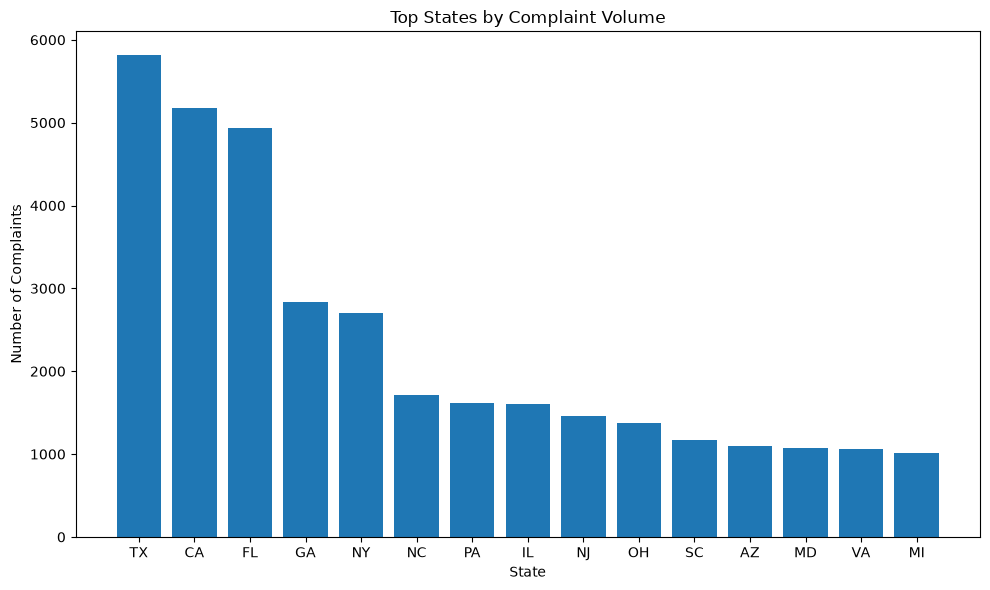

In [38]:
top_states = state_counts.head(15)

plt.figure(figsize=(10, 6))

plt.bar(
    top_states.index,
    top_states.values
)

plt.xlabel("State")
plt.ylabel("Number of Complaints")
plt.title("Top States by Complaint Volume")

plt.tight_layout()
plt.show()

### NEW: DATA QUALITY SUMMARY

In [39]:
data_quality_summary = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Total Columns",
        "Duplicate Rows",
        "Missing Values",
        "Unique Complaint IDs",
        "Negative Response Days"
    ],
    "Value": [
        len(clean_data),
        len(clean_data.columns),
        clean_data.duplicated().sum(),
        clean_data.isnull().sum().sum(),
        clean_data["complaint_id"].nunique(),
        (clean_data["response_days"] < 0).sum()
    ]
})

data_quality_summary

,Metric,Value
0,Total Records,47053
1,Total Columns,17
2,Duplicate Rows,0
3,Missing Values,0
4,Unique Complaint IDs,47053
5,Negative Response Days,0


### FINAL PROJECT DATASET VERIFICATION

In [40]:
print("=" * 70)
print("FINAL PROJECT DATASET VERIFICATION")
print("=" * 70)

print("\nRows:", clean_data.shape[0])
print("Columns:", clean_data.shape[1])

print("\nDuplicate Rows:")
print(clean_data.duplicated().sum())

print("\nTotal Missing Values:")
print(clean_data.isnull().sum().sum())

print("\nUnique Complaint IDs:")
print(clean_data["complaint_id"].nunique())

print("\nNegative Response Days:")
print((clean_data["response_days"] < 0).sum())

FINAL PROJECT DATASET VERIFICATION

Rows: 47053
Columns: 17

Duplicate Rows:
0

Total Missing Values:
0

Unique Complaint IDs:
47053

Negative Response Days:
0


<Figure size 1200x700 with 0 Axes>

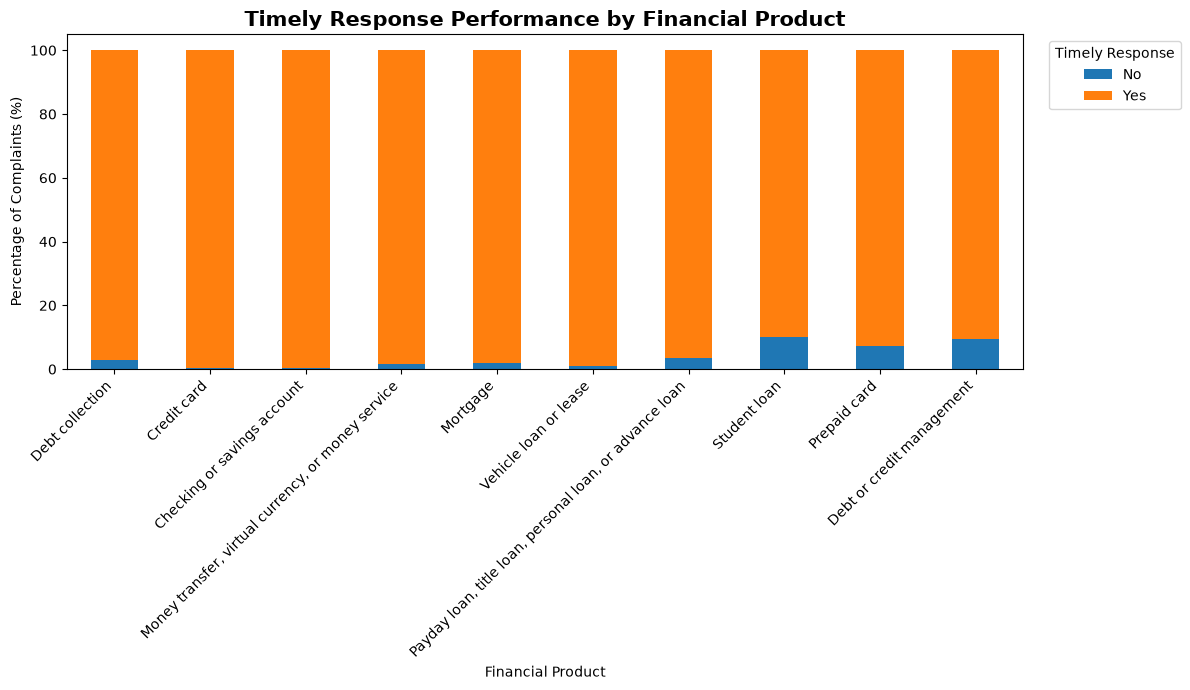

In [42]:
# -> Compare financial products with timely response status

product_timely = pd.crosstab(
    clean_data["product"],
    clean_data["timely_response"],
    normalize="index"
) * 100

top_products = (
    clean_data["product"]
    .value_counts()
    .head(10)
    .index
)

product_timely = product_timely.loc[top_products]

plt.figure(figsize=(12, 7))

product_timely.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.title(
    "Timely Response Performance by Financial Product",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Financial Product")
plt.ylabel("Percentage of Complaints (%)")

plt.xticks(rotation=45, ha="right")

plt.legend(
    title="Timely Response",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

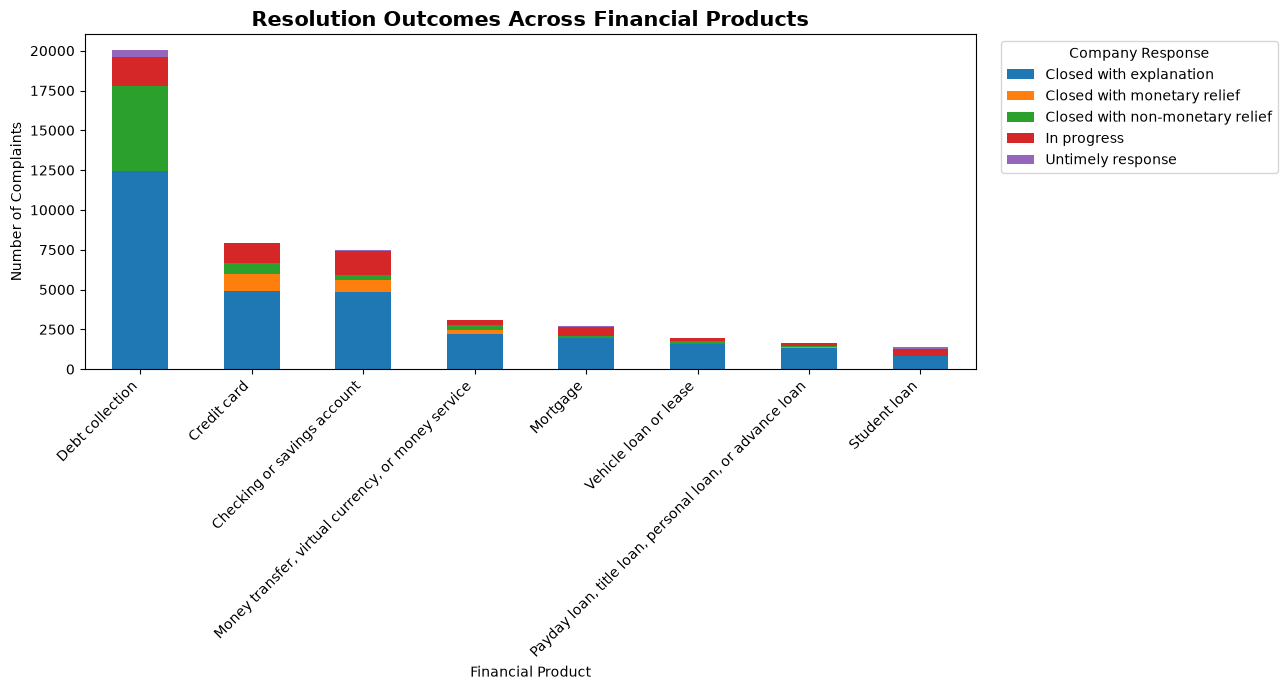

In [43]:
# -> Compare financial products with company resolution outcomes

product_resolution = pd.crosstab(
    clean_data["product"],
    clean_data["company_response_to_consumer"]
)

top_products = (
    clean_data["product"]
    .value_counts()
    .head(8)
    .index
)

product_resolution = product_resolution.loc[top_products]

product_resolution.plot(
    kind="bar",
    stacked=True,
    figsize=(13, 7)
)

plt.title(
    "Resolution Outcomes Across Financial Products",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Financial Product")
plt.ylabel("Number of Complaints")

plt.xticks(rotation=45, ha="right")

plt.legend(
    title="Company Response",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

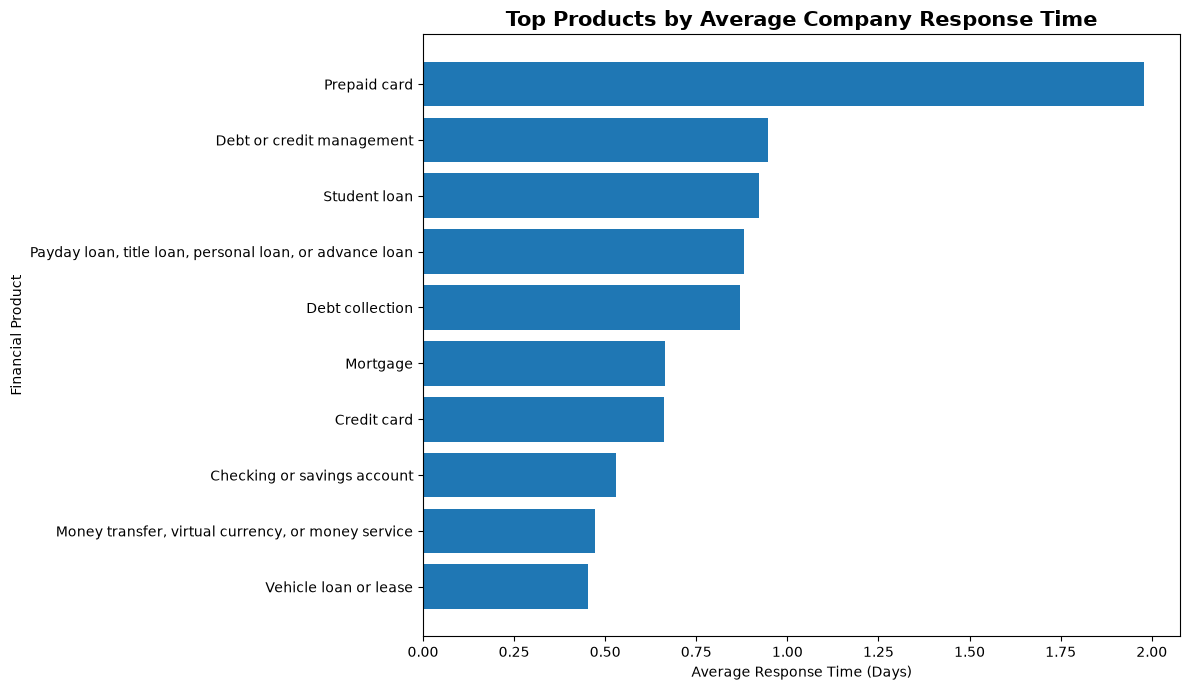

In [47]:
# -> Compare average response time across financial products

average_response = (
    clean_data
    .groupby("product")["response_days"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 7))

plt.barh(
    average_response.index[::-1],
    average_response.values[::-1]
)

plt.title(
    "Top Products by Average Company Response Time",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Average Response Time (Days)")
plt.ylabel("Financial Product")

plt.tight_layout()
plt.show()

### SAVE CLEAN DATASET

In [41]:
clean_data.to_csv(r"D:\AI & ML\Consumer_Financial_Complaints\Dataset\Consumer_Financial_Complaints_Cleaned.csv",index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
